In [7]:
from firedrake import Mesh, FunctionSpace
from firedrake import Function

from manifold_matern.cli import argument_parser
from manifold_matern.manifold_matern_gp import ManifoldMaternGP
from manifold_matern.laplace_eigenvalues import get_eigenpairs

from manifold_matern.utils import export_fun, construct_mesh_graph, \
    convert_to_firedrake_function

import numpy as np
import os

import matplotlib.pyplot as plt

import plotly.graph_objects as go

import random

#from sklearn.metrics import mean_squared_error

import json

#import tqdm

In [8]:
def construct_ground_truth(mesh):
    import networkx as nx

    mesh_graph = construct_mesh_graph(mesh)

    geodesics = nx.shortest_path_length(mesh_graph, source=0, weight='weight')

    N = mesh.num_vertices()

    ground_truth = np.zeros((N))
    period = 2*np.pi / 0.3 * 2
    for i in range(N):
        ground_truth[i] = 2 * np.sin(geodesics.get(i) * period + 0.3)

    return ground_truth

In [9]:
mesh = Mesh('resources/meshes/dragon_connected.msh', dim=3)

print('Constructing ground truth. It may take a while')

ground_truth = construct_ground_truth(mesh)

V = FunctionSpace(mesh, "Lagrange", 1)


Constructing ground truth. It may take a while


In [10]:

# num_eigenpairs = 500 # args.num_eigenpairs # 500 is the default according to the github repo

num_eigenpairs = 1000 # 1000

eigenpairs = get_eigenpairs(mesh, V, num_eigvals=num_eigenpairs,
                                eps_target=1e-10)



In [11]:
# Load the saved data
data = np.load('/pscratch/sd/m/malghal/Flexible_kernels/Dragon/dragon_complete_dataset_from_firedrake.npz')

# Extract all the data
vertices = data['vertices']                      # All mesh vertices (N, 3)
ground_truth = data['ground_truth']              # Ground truth values (N,)


# Step 1: First sample the subset of points
np.random.seed(2355)
N_VERTICES_SUBSET = 100179# 50000
# Extract subset of vertices and ground truth
vertices_subset = vertices[:N_VERTICES_SUBSET,:]
ground_truth_subset = ground_truth[:N_VERTICES_SUBSET]


# Step 3: Now split the subset into train and test
n_train = 100
n_test = 5000

# Sample ALL indices at once, then split
indices_all = np.random.choice(N_VERTICES_SUBSET, size=n_train + n_test, replace=False)

# Split into train and test
indices_train = indices_all[:n_train]
indices_test = indices_all[n_train:]

# Extract data
X = indices_train
y_train = ground_truth_subset[indices_train]

x_test = indices_test
y_test = ground_truth_subset[indices_test]

print(f"Training points: {len(indices_train)}")
print(f"Test points: {len(indices_test)}")

Training points: 100
Test points: 5000


In [12]:
eigenpairs[0].shape

(1018,)

In [13]:
gp = ManifoldMaternGP(mesh, V, X, y_train, eigenpairs)
gp.kappa.constrain_bounded(0.01, 5.0)
gp.sigma_n.fix(1e-6) #15)
gp.sigma_f.constrain_bounded(1., 100000.0)

np.random.seed(2)

print('Optimizing MLL. It may take a while')
gp.optimize_restarts(num_restarts=5)

print('Optimization finished. Proceeding to output')
mean, variance = gp.predict()
#std = np.nan_to_num(np.sqrt(variance))
std = np.nan_to_num(np.sqrt(np.maximum(variance, 0)))

#samples = gp.posterior_samples(1)

print("Prediction done")

reconstraining parameters manifold_matern_gp.kappa
reconstraining parameters manifold_matern_gp.sigma_f


Optimizing MLL. It may take a while
Optimization restart 1/5, f = 3520239.216353424
Optimization restart 2/5, f = 52.31588795213895
Optimization restart 3/5, f = 52.31588780494398
Optimization restart 4/5, f = 52.31589716958189
Optimization restart 5/5, f = 52.31590276278118
Optimization finished. Proceeding to output
Prediction done


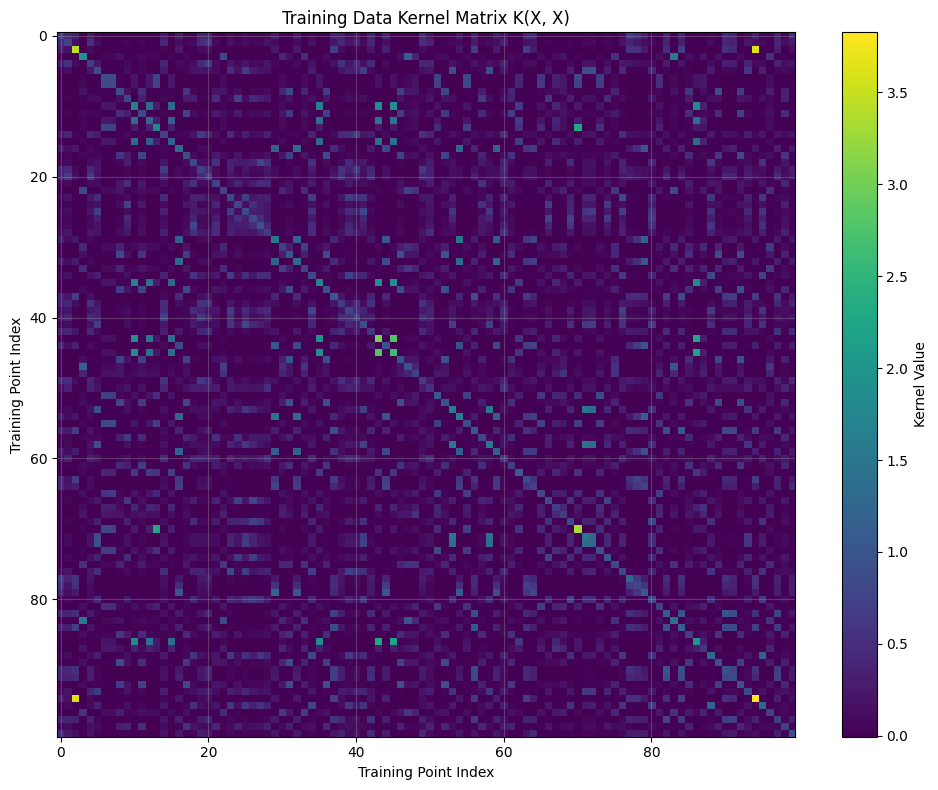

In [8]:
# Get current spectral density
S = gp.eval_S(gp.kappa, gp.sigma_f)

# Get kernel matrix K(X, X) for training points
K_train = gp.eval_K(S)

# Create the visualization
plt.figure(figsize=(10, 8))
im = plt.imshow(K_train[0:100,0:100], cmap='viridis', aspect='auto')
plt.colorbar(im, label='Kernel Value')
plt.title('Training Data Kernel Matrix K(X, X)')
plt.xlabel('Training Point Index')
plt.ylabel('Training Point Index')

# Add grid for better readability
plt.grid(True, alpha=0.3)

# Optionally, add text annotations for small matrices
if K_train.shape[0] <= 20:  # Only for small matrices
    for i in range(K_train.shape[0]):
        for j in range(K_train.shape[1]):
            plt.text(j, i, f'{K_train[i,j]:.2f}', 
                    ha='center', va='center', fontsize=8)

plt.tight_layout()
plt.show()


RMSE:  0.32980268758039677


Text(0, 0.5, 'predicted')

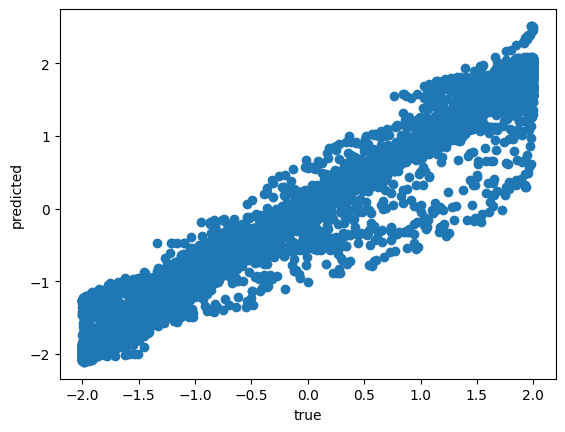

In [9]:
def rmse_manual(y_true, y_pred):
    
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

mean, variance = gp.predict()
mean_test = mean[x_test]

my_rmse = rmse_manual(y_test,mean_test)
print("RMSE: ", my_rmse)

#plt.scatter(ground_truth, mean)
plt.scatter(y_test, mean_test)
plt.xlabel("true")
plt.ylabel("predicted")

In [10]:
from scipy.stats import norm

def _crps_s(x, mu, sigma):
        res = abs(sigma * ((1. / np.sqrt(np.pi))
                           - 2. * norm.pdf((x - mu) / sigma)
                           - (((x - mu) / sigma) * (2. * norm.cdf((x - mu) / sigma) - 1.))))
        return np.mean(res), np.sqrt(np.var(res))

def crps(mean, sigma, y_test):
    """
    This function calculates the continuous rank probability score.

    Parameters
    ----------
    x_test : np.ndarray
        A numpy array of shape (V x D), interpreted as  an array of input point positions.
    y_test : np.ndarray
        A numpy array of shape (V x No) in the multi-output case. These are the y data to compare against.

    Return
    ------
    CRPS, standard dev. of CRPS : (float, float)
    """
    
    assert mean.shape == sigma.shape == y_test.shape, (mean.shape, sigma.shape, y_test.shape)
    r = _crps_s(y_test, mean, sigma)
    return r


mean, variance = gp.predict()
std = np.nan_to_num(np.sqrt(np.maximum(variance, 0)))

posterior_mean = mean[x_test]
posterior_std = std[x_test]

my_crsp = crps(posterior_mean, posterior_std, y_test)
print("Mean CRPS: ", my_crsp[0])
print("std CRPS: ", my_crsp[1])

print(posterior_mean[0], posterior_std[0])

Mean CRPS:  0.14882781306075737
std CRPS:  0.1632766905458175
1.6075169232304427 0.33583778490996624


In [11]:
def picp(mu, sigma, y_true, interval=0.95):
        """
        Computes the Prediction Interval Coverage Probability (PICP)
        for a Gaussian Process posterior.

        Parameters
        ----------
        x_test : array-like, shape (N,dim)
        y_true : array-like, shape (N,)
            True values of the target variable.
        interval : float, optional
            Confidence interval (default 0.95 for 95% intervals).

        Returns
        -------
        picp : float
            Prediction Interval Coverage Probability
        lower_bounds : ndarray
            Lower bounds of prediction intervals
        upper_bounds : ndarray
            Upper bounds of prediction intervals
        """

        z = norm.ppf(1 - (1 - interval) / 2)
        lower_bounds = mu - z * sigma
        upper_bounds = mu + z * sigma

        inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
        picp = np.mean(inside)

        return picp

mean, variance = gp.predict()
variance = variance+ gp.sigma_n**2
std = np.nan_to_num(np.sqrt(np.maximum(variance, 0)))

posterior_mean = mean[x_test]
posterior_std = std[x_test]


my_picp = picp(posterior_mean, posterior_std, y_test)
my_picp

0.9644

In [35]:
def plot_example_plotly(filename, mesh, V, function_values, X, vmin, vmax, 
                       colormap='plasma', title="Function Plot"):
    
    # Create Firedrake function (following their pattern)
    fn = Function(V)
    fn.vector()[:] = function_values
    
    # Get mesh coordinates - use the function space coordinates
    coords = V.mesh().coordinates.dat.data_ro
    
    # Get the function values for plotting
    values = fn.vector()[:]
    
    # Create scatter plot of data points if provided
    data_traces = []
    if X is not None and len(X) > 0:
        data_coords = coords[X]
        data_values = values[X]
        
        data_traces.append(
            go.Scatter3d(
                x=data_coords[:, 0],
                y=data_coords[:, 1], 
                z=data_coords[:, 2],
                mode='markers',
                marker=dict(
                    size=8,
                    color='red',
                    symbol='diamond'
                ),
                showlegend=False  # Hide from legend
            )
        )
    
    # Create main function plot
    main_trace = go.Scatter3d(
        x=coords[:, 0],
        y=coords[:, 1],
        z=coords[:, 2],
        mode='markers',
        marker=dict(
            size=3,
            color=values,
            colorscale=colormap,
            cmin=vmin,
            cmax=vmax,
            showscale=True,
            colorbar=dict(title="")  # Empty title for colorbar
        ),
        showlegend=False  # Hide from legend
    )
    
    # Create figure
    fig = go.Figure(data=[main_trace] + data_traces)
    
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis_title='X',
            yaxis_title='Y', 
            zaxis_title='Z',
            camera=dict(
                eye=dict(x=1.5, y=1.5, z=1.5)
            )
        ),
        width=800,
        height=600
    )
    
    # # Save files
    # fig.write_html(filename)
        
     # Show plot
    #fig.show()

    return fig

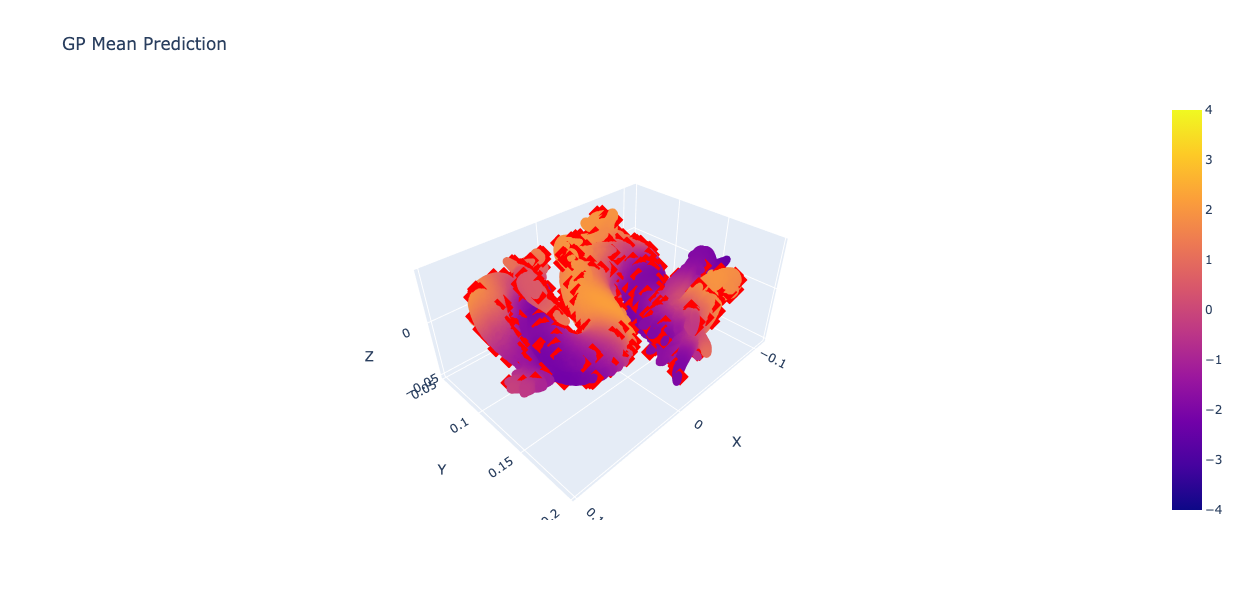

In [36]:
output_dir = "My_plots/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)
     
# # Plot ground truth
vmin, vmax = -4., 4.
# plot_example_plotly(os.path.join(output_dir, '1_ground_truth.html'),
#                    mesh, V, ground_truth, X, vmin, vmax, 
#                    title="Ground Truth")

# Plot mean prediction
plot_example_plotly(os.path.join(output_dir, '1_mean.html'),
                   mesh, V, mean, X, vmin, vmax,
                   title="GP Mean Prediction")

# # Plot standard deviation  
# plot_example_plotly(os.path.join(output_dir, '1_std.html'),
#                    mesh, V, std, X, std.min(), std.max(), 
#                    colormap='Viridis', title="GP Standard Deviation")

# # Plot samples
# for s in range(len(samples)):
#     plot_example_plotly(os.path.join(output_dir, f'1_sample_{s}.html'),
#                        mesh, V, samples[s], X, vmin, vmax,
#                        title=f"Sample {s}")

# Saving results to use them for gpcam

In [10]:
# # Load and process exactly like original repo
# mesh = Mesh('resources/meshes/dragon_connected.msh', dim=3)
# vertices = mesh.coordinates.dat.data_ro.copy()
# mesh_graph = construct_mesh_graph(mesh)

# # Compute ground truth
# geodesics = nx.shortest_path_length(mesh_graph, source=0, weight='weight')
# N = mesh.num_vertices()
# ground_truth = np.zeros((N))
# period = 2*np.pi / 0.3 * 2
# for i in range(N):
#     ground_truth[i] = 2 * np.sin(geodesics.get(i) * period + 0.3)

# # Training data
# indices_train = np.unique([3316, 10960, 24947, 33498, 33513, 34844, 35740, 35830, 36026,
#          36654, 36727, 37597, 39066, 39886, 40050, 41165, 41387, 41430,
#          42420, 43012, 43383, 45296, 45796, 47431, 48346, 48779, 49033,
#          49127, 50374, 50878, 51132, 51168, 51175, 55643, 55863,
#          56414, 56568, 56933, 57130, 57168, 57536, 60028, 61432, 61915,
#          62936, 63657, 64280, 64542, 75551, 87643, 95423])

# # Compact geodesic distances (training → all)
# train_to_all_geodesics = np.full((len(indices_train), N), np.inf)
# for i, train_idx in enumerate(indices_train):
#     distances = nx.shortest_path_length(mesh_graph, source=train_idx, weight='weight')
#     for vertex_idx, dist in distances.items():
#         train_to_all_geodesics[i, vertex_idx] = dist

# # Save EVERYTHING you'll need for gpCAM
# np.savez_compressed('dragon_complete_dataset.npz',
#                     # Mesh data
#                     vertices=vertices,                    # All vertex coordinates
#                     faces=mesh.topology_dm.getStratumIS("depth", 0).getIndices(),  # Face connectivity
                    
#                     # Ground truth
#                     ground_truth=ground_truth,
                    
#                     # Training data  
#                     indices_train=indices_train,
#                     x_train=vertices[indices_train],
#                     y_train=ground_truth[indices_train],
                    
#                     # Geodesic distances (compact)
#                     train_to_all_geodesics=train_to_all_geodesics,
                    
#                     # Metadata
#                     n_vertices=N,
#                     source_vertex=0,  # Used for ground truth computation
#                     period=period
#                     )

# print("✅ Complete dataset saved - no more Firedrake needed!")

# Computing full geodesic matrix

In [29]:
# # Run this in Firedrake environment
# import numpy as np
# import time
# import os
# import networkx as nx
# from firedrake import Mesh
# from manifold_matern.utils import construct_mesh_graph

# print("🚀 Starting Partial Geodesic Distance Matrix Computation (with checkpoints)")
# print("=" * 70)

# # Configuration
# N_VERTICES_SUBSET = 50000  # ← Only compute for first 50k vertices
# OUTPUT_FILE = f'dragon_geodesic_matrix_{N_VERTICES_SUBSET}.npy'
# CHECKPOINT_FILE = f'dragon_geodesic_checkpoint_{N_VERTICES_SUBSET}.npz'
# SAVE_INTERVAL = 1000  # Save every 1000 vertices

# # Load mesh and create graph
# print("🔧 Loading mesh and constructing graph...")
# mesh = Mesh('resources/meshes/dragon_connected.msh', dim=3)
# vertices_full = mesh.coordinates.dat.data_ro.copy()
# mesh_graph_full = construct_mesh_graph(mesh)

# # Extract subset
# vertices = vertices_full[:N_VERTICES_SUBSET]
# n_vertices = len(vertices)

# # Create subgraph with only these vertices
# print(f"🔧 Creating subgraph for first {n_vertices:,} vertices...")
# mesh_graph = mesh_graph_full.subgraph(range(n_vertices)).copy()

# print(f"✅ Mesh loaded: {len(vertices_full):,} total vertices")
# print(f"✅ Using subset: {n_vertices:,} vertices")
# print(f"✅ Subgraph created: {mesh_graph.number_of_nodes():,} nodes, {mesh_graph.number_of_edges():,} edges")
# print(f"Memory required: {n_vertices * n_vertices * 4 / 1e9:.1f} GB")

# # Check for existing checkpoint
# start_vertex = 0
# start_time = time.time()

# if os.path.exists(CHECKPOINT_FILE):
#     print(f"\n📁 Found checkpoint file: {CHECKPOINT_FILE}")
#     try:
#         checkpoint_data = np.load(CHECKPOINT_FILE)
#         start_vertex = int(checkpoint_data['last_completed_vertex']) + 1
#         checkpoint_start_time = float(checkpoint_data['start_time'])
        
#         # Use existing start time if resuming
#         start_time = checkpoint_start_time
        
#         print(f"🔄 Resuming from vertex {start_vertex:,}/{n_vertices:,}")
#         print(f"   Previously elapsed: {checkpoint_data.get('elapsed_time', 0)/60:.1f} minutes")
        
#         # Load existing matrix
#         if os.path.exists(OUTPUT_FILE):
#             print(f"✅ Found existing matrix file: {OUTPUT_FILE}")
#             geo_dist_full = np.memmap(OUTPUT_FILE,
#                                       dtype=np.float32,
#                                       mode='r+',
#                                       shape=(n_vertices, n_vertices))
#         else:
#             print(f"⚠️  Checkpoint exists but matrix file missing. Starting fresh.")
#             start_vertex = 0
#             geo_dist_full = np.memmap(OUTPUT_FILE,
#                                       dtype=np.float32,
#                                       mode='w+',
#                                       shape=(n_vertices, n_vertices))
#             geo_dist_full[:] = np.inf
#             np.fill_diagonal(geo_dist_full, 0.0)
#             geo_dist_full.flush()
            
#     except Exception as e:
#         print(f"❌ Error loading checkpoint: {e}")
#         print("🆕 Starting fresh computation...")
#         start_vertex = 0
#         start_time = time.time()
        
#         # Create new matrix
#         geo_dist_full = np.memmap(OUTPUT_FILE,
#                                   dtype=np.float32,
#                                   mode='w+',
#                                   shape=(n_vertices, n_vertices))
#         geo_dist_full[:] = np.inf
#         np.fill_diagonal(geo_dist_full, 0.0)
#         geo_dist_full.flush()
# else:
#     print("🆕 No checkpoint found, starting fresh computation...")
    
#     # Create new matrix
#     geo_dist_full = np.memmap(OUTPUT_FILE,
#                               dtype=np.float32,
#                               mode='w+',
#                               shape=(n_vertices, n_vertices))
#     geo_dist_full[:] = np.inf
#     np.fill_diagonal(geo_dist_full, 0.0)
#     geo_dist_full.flush()
#     print(f"✅ Matrix initialized with shape {geo_dist_full.shape}")

# print(f"\n🚀 Starting computation from vertex {start_vertex:,}")
# print(f"💾 Checkpoints will be saved every {SAVE_INTERVAL} vertices")
# print("-" * 70)

# # Computation loop
# batch_size = 100

# for batch_start in range(start_vertex, n_vertices, batch_size):
#     batch_end = min(batch_start + batch_size, n_vertices)
    
#     # Progress reporting
#     elapsed = time.time() - start_time
#     if batch_start > start_vertex:
#         vertices_done = batch_start - start_vertex
#         if vertices_done > 0:
#             est_total = elapsed * (n_vertices - start_vertex) / vertices_done
#             remaining = est_total - elapsed
#             pct = batch_start / n_vertices * 100
            
#             print(f"Vertex {batch_start:6,}/{n_vertices:,} ({pct:5.1f}%) - "
#                   f"Elapsed: {elapsed/60:6.1f}m - ETA: {remaining/60:6.1f}m")
    
#     # Compute batch
#     for source in range(batch_start, batch_end):
#         try:
#             # Compute shortest paths from this source
#             distances_dict = nx.shortest_path_length(mesh_graph, 
#                                                      source=source, 
#                                                      weight='weight')
            
#             # Fill BOTH directions to ensure symmetry
#             for target, dist in distances_dict.items():
#                 geo_dist_full[source, target] = dist
#                 geo_dist_full[target, source] = dist  # Enforce symmetry
                
#         except Exception as e:
#             print(f"❌ Error at vertex {source}: {e}")
#             # Fill with inf for failed vertices
#             geo_dist_full[source, :] = np.inf
#             geo_dist_full[:, source] = np.inf
#             geo_dist_full[source, source] = 0.0
    
#     # Flush to disk
#     geo_dist_full.flush()
    
#     # Save checkpoint periodically
#     if (batch_end - start_vertex) >= SAVE_INTERVAL and \
#        (batch_end - start_vertex) % SAVE_INTERVAL < batch_size:
        
#         elapsed_time = time.time() - start_time
#         print(f"💾 Saving checkpoint at vertex {batch_end-1:,}...")
        
#         np.savez_compressed(CHECKPOINT_FILE,
#                            last_completed_vertex=batch_end - 1,
#                            total_vertices=n_vertices,
#                            start_time=start_time,
#                            elapsed_time=elapsed_time)
        
#         print(f"✅ Checkpoint saved (elapsed: {elapsed_time/60:.1f} min)")

# # Final flush
# geo_dist_full.flush()
# total_time = time.time() - start_time

# print("\n" + "=" * 70)
# print(f"✅ Computation complete in {total_time/60:.1f} minutes")

# # Verification
# print("\n🔍 Running verification checks...")

# # 1. Check diagonal
# diag_sample = np.array([geo_dist_full[i, i] for i in range(min(100, n_vertices))])
# print(f"1. Diagonal (first 100): all zeros? {np.all(diag_sample == 0)}")

# # 2. Check symmetry (sample)
# sample_size = min(1000, n_vertices)
# sample_indices = np.random.choice(n_vertices, size=sample_size, replace=False)
# is_symmetric = True

# for i in sample_indices[:100]:
#     for j in sample_indices[:100]:
#         if abs(geo_dist_full[i, j] - geo_dist_full[j, i]) > 1e-5:
#             print(f"   Asymmetry at [{i},{j}]: {geo_dist_full[i,j]} vs {geo_dist_full[j,i]}")
#             is_symmetric = False
#             break
#     if not is_symmetric:
#         break

# print(f"2. Symmetry check (sample): {is_symmetric}")

# # 3. Check for infinities
# n_inf_sample = np.sum(np.isinf(geo_dist_full[:1000, :1000]))
# print(f"3. Infinite values (1000x1000 sample): {n_inf_sample}")

# # 4. Check reasonable values
# off_diag_sample = []
# for i in range(min(100, n_vertices)):
#     for j in range(i+1, min(100, n_vertices)):
#         off_diag_sample.append(geo_dist_full[i, j])

# if len(off_diag_sample) > 0:
#     off_diag_sample = np.array(off_diag_sample)
#     finite_vals = off_diag_sample[np.isfinite(off_diag_sample)]
#     if len(finite_vals) > 0:
#         print(f"4. Off-diagonal stats (finite values):")
#         print(f"   Min: {finite_vals.min():.6f}")
#         print(f"   Max: {finite_vals.max():.6f}")
#         print(f"   Mean: {finite_vals.mean():.6f}")
#         print(f"   Median: {np.median(finite_vals):.6f}")

# del geo_dist_full

# # Clean up checkpoint
# if os.path.exists(CHECKPOINT_FILE):
#     os.remove(CHECKPOINT_FILE)
#     print(f"\n🗑️  Removed checkpoint file")

# print(f"\n🎉 COMPLETE! Matrix saved to: {OUTPUT_FILE}")

# # Also save the subset vertices for later use
# np.save(f'dragon_vertices_subset_{N_VERTICES_SUBSET}.npy', vertices)
# print(f"✅ Subset vertices saved to: dragon_vertices_subset_{N_VERTICES_SUBSET}.npy")

In [ ]:
# # Run this in Firedrake environment
# import numpy as np
# import time
# import os
# import networkx as nx
# from firedrake import Mesh
# from manifold_matern.utils import construct_mesh_graph

# print("🚀 Starting Geodesic Distance Matrix Computation (Upper Triangle Only)")
# print("=" * 70)

# # Configuration
# N_VERTICES_SUBSET = 100179  # ← Full mesh
# OUTPUT_FILE = f'dragon_geodesic_matrix_{N_VERTICES_SUBSET}_new.npy'
# CHECKPOINT_FILE = f'dragon_geodesic_checkpoint_{N_VERTICES_SUBSET}_new.npz'
# SAVE_INTERVAL = 5000  # Save every 5000 vertices

# # Load mesh and create graph
# print("🔧 Loading mesh and constructing graph...")
# mesh = Mesh('resources/meshes/dragon_connected.msh', dim=3)
# vertices_full = mesh.coordinates.dat.data_ro.copy()
# mesh_graph_full = construct_mesh_graph(mesh)

# # Extract subset
# vertices = vertices_full[:N_VERTICES_SUBSET]
# n_vertices = len(vertices)

# # Create subgraph with only these vertices
# print(f"🔧 Creating subgraph for first {n_vertices:,} vertices...")
# mesh_graph = mesh_graph_full.subgraph(range(n_vertices)).copy()

# print(f"✅ Mesh loaded: {len(vertices_full):,} total vertices")
# print(f"✅ Using subset: {n_vertices:,} vertices")
# print(f"✅ Subgraph created: {mesh_graph.number_of_nodes():,} nodes, {mesh_graph.number_of_edges():,} edges")
# print(f"Memory required: {n_vertices * n_vertices * 4 / 1e9:.1f} GB")

# # Check for existing checkpoint
# start_vertex = 0
# start_time = time.time()

# if os.path.exists(CHECKPOINT_FILE):
#     print(f"\n📁 Found checkpoint file: {CHECKPOINT_FILE}")
#     try:
#         checkpoint_data = np.load(CHECKPOINT_FILE)
#         start_vertex = int(checkpoint_data['last_completed_vertex']) + 1
#         checkpoint_start_time = float(checkpoint_data['start_time'])
        
#         # Use existing start time if resuming
#         start_time = checkpoint_start_time
        
#         print(f"🔄 Resuming from vertex {start_vertex:,}/{n_vertices:,}")
#         print(f"   Previously elapsed: {checkpoint_data.get('elapsed_time', 0)/60:.1f} minutes")
        
#         # Load existing matrix
#         if os.path.exists(OUTPUT_FILE):
#             print(f"✅ Found existing matrix file: {OUTPUT_FILE}")
#             geo_dist_full = np.memmap(OUTPUT_FILE,
#                                       dtype=np.float32,
#                                       mode='r+',
#                                       shape=(n_vertices, n_vertices))
#         else:
#             print(f"⚠️  Checkpoint exists but matrix file missing. Starting fresh.")
#             start_vertex = 0
#             geo_dist_full = np.memmap(OUTPUT_FILE,
#                                       dtype=np.float32,
#                                       mode='w+',
#                                       shape=(n_vertices, n_vertices))
#             geo_dist_full[:] = np.inf
#             np.fill_diagonal(geo_dist_full, 0.0)
#             geo_dist_full.flush()
            
#     except Exception as e:
#         print(f"❌ Error loading checkpoint: {e}")
#         print("🆕 Starting fresh computation...")
#         start_vertex = 0
#         start_time = time.time()
        
#         # Create new matrix
#         geo_dist_full = np.memmap(OUTPUT_FILE,
#                                   dtype=np.float32,
#                                   mode='w+',
#                                   shape=(n_vertices, n_vertices))
#         geo_dist_full[:] = np.inf
#         np.fill_diagonal(geo_dist_full, 0.0)
#         geo_dist_full.flush()
# else:
#     print("🆕 No checkpoint found, starting fresh computation...")
    
#     # Create new matrix
#     geo_dist_full = np.memmap(OUTPUT_FILE,
#                               dtype=np.float32,
#                               mode='w+',
#                               shape=(n_vertices, n_vertices))
#     geo_dist_full[:] = np.inf
#     np.fill_diagonal(geo_dist_full, 0.0)
#     geo_dist_full.flush()
#     print(f"✅ Matrix initialized with shape {geo_dist_full.shape}")

# print(f"\n🚀 Starting computation from vertex {start_vertex:,}")
# print(f"💾 Checkpoints will be saved every {SAVE_INTERVAL} vertices")
# print(f"⚡ Computing UPPER TRIANGLE ONLY (will mirror at end)")
# print("-" * 70)

# # Computation loop
# batch_size = 100
# last_checkpoint_vertex = start_vertex - (start_vertex % SAVE_INTERVAL)

# for batch_start in range(start_vertex, n_vertices, batch_size):
#     batch_end = min(batch_start + batch_size, n_vertices)
    
#     # Progress reporting
#     elapsed = time.time() - start_time
#     if batch_start > start_vertex:
#         vertices_done = batch_start - start_vertex
#         if vertices_done > 0:
#             est_total = elapsed * (n_vertices - start_vertex) / vertices_done
#             remaining = est_total - elapsed
#             pct = batch_start / n_vertices * 100
            
#             print(f"Vertex {batch_start:6,}/{n_vertices:,} ({pct:5.1f}%) - "
#                   f"Elapsed: {elapsed/60:6.1f}m - ETA: {remaining/60:6.1f}m")
    
#     # Compute batch - UPPER TRIANGLE ONLY
#     for source in range(batch_start, batch_end):
#         try:
#             # Compute shortest paths from this source
#             distances_dict = nx.shortest_path_length(mesh_graph, 
#                                                      source=source, 
#                                                      weight='weight')
            
#             # Fill ONLY upper triangle (where target >= source)
#             for target, dist in distances_dict.items():
#                 if target >= source:
#                     geo_dist_full[source, target] = dist
                
#         except Exception as e:
#             print(f"❌ Error at vertex {source}: {e}")
#             # Fill with inf for failed vertices
#             geo_dist_full[source, source:] = np.inf
#             geo_dist_full[source, source] = 0.0
    
#     # Flush to disk
#     geo_dist_full.flush()
    
#     # Save checkpoint periodically
#     if batch_end >= last_checkpoint_vertex + SAVE_INTERVAL:
#         elapsed_time = time.time() - start_time
#         print(f"💾 Saving checkpoint at vertex {batch_end-1:,}...")
        
#         np.savez_compressed(CHECKPOINT_FILE,
#                            last_completed_vertex=batch_end - 1,
#                            total_vertices=n_vertices,
#                            start_time=start_time,
#                            elapsed_time=elapsed_time)
        
#         last_checkpoint_vertex = batch_end - (batch_end % SAVE_INTERVAL)
#         print(f"✅ Checkpoint saved (elapsed: {elapsed_time/60:.1f} min)")

# # Final flush
# geo_dist_full.flush()
# computation_time = time.time() - start_time

# print("\n" + "=" * 70)
# print(f"✅ Upper triangle computation complete in {computation_time/60:.1f} minutes ({computation_time/3600:.2f} hours)")

🚀 Starting Geodesic Distance Matrix Computation (Upper Triangle Only)
🔧 Loading mesh and constructing graph...
🔧 Creating subgraph for first 100,179 vertices...
✅ Mesh loaded: 100,179 total vertices
✅ Using subset: 100,179 vertices
✅ Subgraph created: 100,179 nodes, 301,167 edges
Memory required: 40.1 GB
🆕 No checkpoint found, starting fresh computation...
✅ Matrix initialized with shape (100179, 100179)

🚀 Starting computation from vertex 0
💾 Checkpoints will be saved every 5000 vertices
⚡ Computing UPPER TRIANGLE ONLY (will mirror at end)
----------------------------------------------------------------------
Vertex    100/100,179 (  0.1%) - Elapsed:    3.0m - ETA: 3010.1m
Vertex    200/100,179 (  0.2%) - Elapsed:    3.7m - ETA: 1828.5m
Vertex    300/100,179 (  0.3%) - Elapsed:    4.3m - ETA: 1427.9m
Vertex    400/100,179 (  0.4%) - Elapsed:    4.9m - ETA: 1224.7m
Vertex    500/100,179 (  0.5%) - Elapsed:    5.5m - ETA: 1105.9m
Vertex    600/100,179 (  0.6%) - Elapsed:    6.2m - ETA: 

In [3]:
# import numpy as np
# import time

# print("="*70)
# print("🔄 FAST GEODESIC MATRIX MIRRORING")
# print("="*70)

# N_VERTICES = 100179
# INPUT_FILE = f'dragon_geodesic_matrix_{N_VERTICES}_new.npy'

# print(f"\n📂 Loading matrix: {INPUT_FILE}")
# geo_dist = np.memmap(INPUT_FILE,
#                      dtype=np.float32,
#                      mode='r+',  # Read-write mode
#                      shape=(N_VERTICES, N_VERTICES))

# print(f"✅ Loaded: {geo_dist.shape}")

# # ===== FAST BATCH TRANSPOSE MIRRORING =====
# print("\n🔄 Mirroring upper triangle to lower (batch method)...")
# print("="*70)

# mirror_start = time.time()

# # Process in large blocks for efficiency
# block_size = 1000  # Process 1000x1000 blocks at a time

# for i in range(0, N_VERTICES, block_size):
#     i_end = min(i + block_size, N_VERTICES)
    
#     # Only process blocks on or above the diagonal
#     for j in range(i, N_VERTICES, block_size):
#         j_end = min(j + block_size, N_VERTICES)
        
#         # Read block from upper triangle
#         upper_block = geo_dist[i:i_end, j:j_end].copy()
        
#         # Write transposed to lower triangle
#         # (Skip when i==j since that's the diagonal block)
#         if i != j:
#             geo_dist[j:j_end, i:i_end] = upper_block.T
#         else:
#             # For diagonal blocks, only copy upper triangle within the block
#             for local_row in range(len(upper_block)):
#                 global_row = i + local_row
#                 if global_row + 1 < N_VERTICES:
#                     # Copy rest of row to corresponding column
#                     n_copy = min(i_end - global_row - 1, N_VERTICES - global_row - 1)
#                     if n_copy > 0:
#                         geo_dist[global_row+1:global_row+1+n_copy, global_row] = \
#                             upper_block[local_row, local_row+1:local_row+1+n_copy]
    
#     # Progress reporting
#     pct = 100 * i_end / N_VERTICES
#     elapsed = time.time() - mirror_start
#     if i > 0:
#         eta = elapsed * (N_VERTICES - i_end) / i_end / 60
#         print(f"  Block {i:6,}-{i_end:6,} ({pct:5.1f}%) - Elapsed: {elapsed/60:.1f}m - ETA: {eta:.1f}m")
#     else:
#         print(f"  Block {i:6,}-{i_end:6,} ({pct:5.1f}%)")
    
#     # Flush every few blocks
#     if i % (block_size * 5) == 0:
#         geo_dist.flush()

# # Final flush
# geo_dist.flush()

# mirror_time = time.time() - mirror_start
# print(f"\n✅ Mirroring complete in {mirror_time/60:.1f} minutes ({mirror_time/3600:.2f} hours)")

# # Quick verification
# print("\n🔍 Quick verification...")
# print("Checking symmetry on sample...")
# sample_idx = [0, 100, 1000, 10000, 50000]
# is_symmetric = True
# for i in sample_idx:
#     for j in sample_idx:
#         if abs(geo_dist[i, j] - geo_dist[j, i]) > 1e-5:
#             print(f"  ❌ Asymmetry at [{i},{j}]: {geo_dist[i,j]} vs {geo_dist[j,i]}")
#             is_symmetric = False

# if is_symmetric:
#     print("  ✅ Sample check passed - matrix appears symmetric")

# print("\n" + "="*70)
# print("✅ MIRRORING COMPLETE!")
# print("="*70)

# del geo_dist

🔄 FAST GEODESIC MATRIX MIRRORING

📂 Loading matrix: dragon_geodesic_matrix_100179_new.npy
✅ Loaded: (100179, 100179)

🔄 Mirroring upper triangle to lower (batch method)...
  Block      0- 1,000 (  1.0%)
  Block  1,000- 2,000 (  2.0%) - Elapsed: 2.4m - ETA: 120.1m
  Block  2,000- 3,000 (  3.0%) - Elapsed: 3.5m - ETA: 112.8m
  Block  3,000- 4,000 (  4.0%) - Elapsed: 4.7m - ETA: 112.0m
  Block  4,000- 5,000 (  5.0%) - Elapsed: 5.9m - ETA: 112.1m
  Block  5,000- 6,000 (  6.0%) - Elapsed: 6.9m - ETA: 108.7m
  Block  6,000- 7,000 (  7.0%) - Elapsed: 8.1m - ETA: 107.8m
  Block  7,000- 8,000 (  8.0%) - Elapsed: 9.2m - ETA: 106.4m
  Block  8,000- 9,000 (  9.0%) - Elapsed: 10.2m - ETA: 103.7m
  Block  9,000-10,000 ( 10.0%) - Elapsed: 11.4m - ETA: 102.5m
  Block 10,000-11,000 ( 11.0%) - Elapsed: 12.5m - ETA: 101.1m
  Block 11,000-12,000 ( 12.0%) - Elapsed: 13.4m - ETA: 98.7m
  Block 12,000-13,000 ( 13.0%) - Elapsed: 14.5m - ETA: 97.5m
  Block 13,000-14,000 ( 14.0%) - Elapsed: 15.6m - ETA: 96.3m
 

# Diagnostic Computations

🔍 Loading and Testing New Geodesic Matrix

📂 Loading matrix from: dragon_geodesic_matrix_100179_new.npy
✅ Matrix loaded: (100179, 100179)
   Memory size: 40.1 GB

TEST 1: Diagonal Check
----------------------------------------------------------------------
First 10,000 diagonal elements:
  All zeros? True
  Min: 0.0
  Max: 0.0
  Non-zero count: 0
✅ PASSED: Diagonal is all zeros

TEST 2: Symmetry Check
----------------------------------------------------------------------
Checking symmetry on 2000x2000 random sample...
  Max asymmetry: 0.0000000000e+00
  Mean asymmetry: 0.0000000000e+00
  Asymmetric pairs (>1e-5): 0 / 1999000
  Percentage asymmetric: 0.00%
✅ PASSED: Matrix is perfectly symmetric

TEST 3: Value Range Check
----------------------------------------------------------------------
Analyzing first 5000x5000 submatrix:
  Total values: 24,995,000
  Finite non-zero: 24,995,000
  Zeros: 0
  Infinites: 0
  NaNs: 0

Finite value statistics:
  Min: 0.000144
  Max: 0.153244
  Mean: 0.

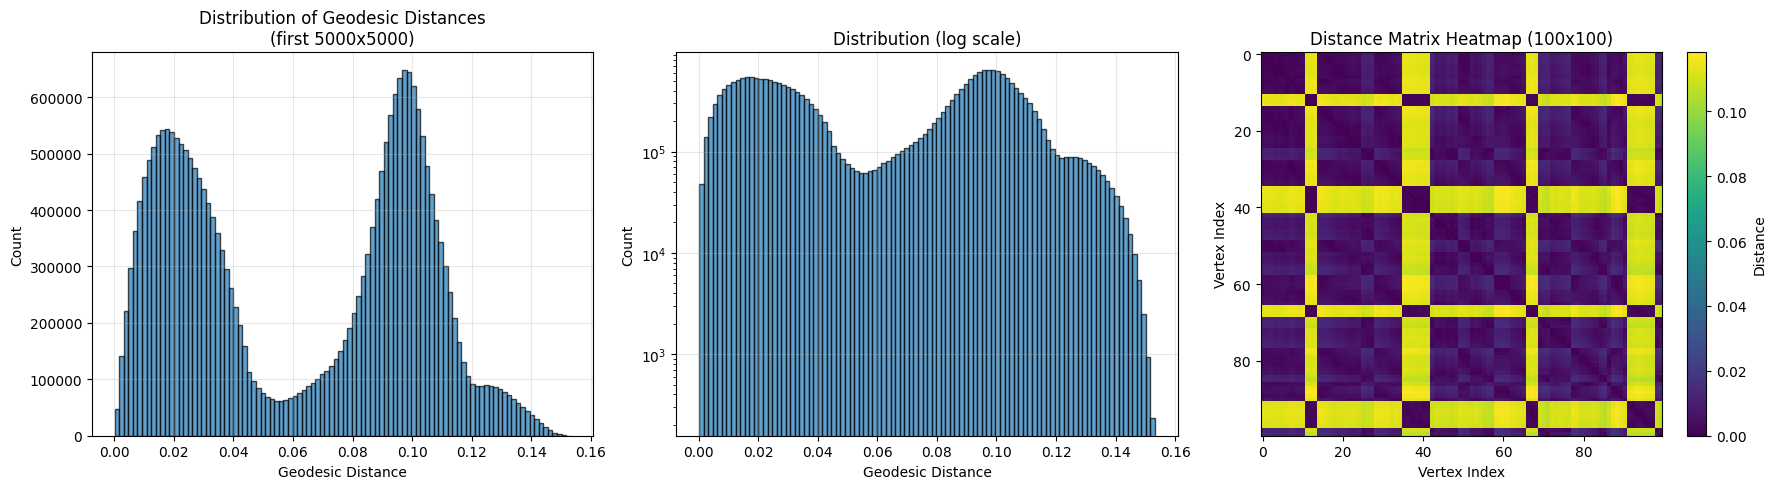


SUMMARY
✅ Test 1: Diagonal check - PASSED
✅ Test 2: Symmetry check - PASSED
✅ Test 3: Value range check - PASSED
✅ Test 4: Connectivity check - PASSED
✅ Test 5: Visualization - COMPLETED

RESULT: 5/5 tests passed
🎉 ALL TESTS PASSED! Matrix is ready for use!



In [4]:
# print("🔍 Loading and Testing New Geodesic Matrix")
# print("=" * 70)

# # Configuration
# N_VERTICES_SUBSET = 100179
# MATRIX_FILE = f'dragon_geodesic_matrix_{N_VERTICES_SUBSET}_new.npy'

# # Load the matrix
# print(f"\n📂 Loading matrix from: {MATRIX_FILE}")
# matrix_size = N_VERTICES_SUBSET

# geodesic_matrix = np.memmap(MATRIX_FILE,
#                             dtype=np.float32,
#                             mode='r',
#                             shape=(matrix_size, matrix_size))

# print(f"✅ Matrix loaded: {geodesic_matrix.shape}")
# print(f"   Memory size: {matrix_size * matrix_size * 4 / 1e9:.1f} GB")

# # ============================================================================
# # TEST 1: Diagonal Check
# # ============================================================================
# print("\n" + "=" * 70)
# print("TEST 1: Diagonal Check")
# print("-" * 70)

# diag_sample_size = min(10000, matrix_size)
# diag_sample = np.array([geodesic_matrix[i, i] for i in range(diag_sample_size)])

# all_zeros = np.all(diag_sample == 0)
# print(f"First {diag_sample_size:,} diagonal elements:")
# print(f"  All zeros? {all_zeros}")
# print(f"  Min: {diag_sample.min()}")
# print(f"  Max: {diag_sample.max()}")
# print(f"  Non-zero count: {np.sum(diag_sample != 0)}")

# if all_zeros:
#     print("✅ PASSED: Diagonal is all zeros")
# else:
#     print(f"❌ FAILED: {np.sum(diag_sample != 0)} non-zero diagonal elements")

# # ============================================================================
# # TEST 2: Symmetry Check
# # ============================================================================
# print("\n" + "=" * 70)
# print("TEST 2: Symmetry Check")
# print("-" * 70)

# # Check symmetry on a sample
# n_sample = min(2000, matrix_size)
# sample_indices = np.random.choice(matrix_size, size=n_sample, replace=False)

# print(f"Checking symmetry on {n_sample}x{n_sample} random sample...")

# subset = np.array(geodesic_matrix[np.ix_(sample_indices, sample_indices)])
# diff = np.abs(subset - subset.T)

# max_asym = diff.max()
# mean_asym = diff.mean()
# asymmetric_pairs = np.sum(diff > 1e-5)
# total_pairs = (n_sample * (n_sample - 1)) // 2

# print(f"  Max asymmetry: {max_asym:.10e}")
# print(f"  Mean asymmetry: {mean_asym:.10e}")
# print(f"  Asymmetric pairs (>1e-5): {asymmetric_pairs} / {total_pairs}")
# print(f"  Percentage asymmetric: {asymmetric_pairs/total_pairs*100:.2f}%")

# if max_asym < 1e-10:
#     print("✅ PASSED: Matrix is perfectly symmetric")
# elif max_asym < 1e-5:
#     print("✅ PASSED: Matrix is symmetric (within numerical precision)")
# else:
#     print(f"❌ FAILED: Matrix is NOT symmetric")

# # ============================================================================
# # TEST 3: Value Range Check
# # ============================================================================
# print("\n" + "=" * 70)
# print("TEST 3: Value Range Check")
# print("-" * 70)

# # Sample values
# sample_size = min(5000, matrix_size)
# sample_matrix = np.array(geodesic_matrix[:sample_size, :sample_size])

# # Get off-diagonal values
# mask = ~np.eye(sample_size, dtype=bool)
# off_diag_values = sample_matrix[mask]

# # Filter finite values
# finite_values = off_diag_values[np.isfinite(off_diag_values) & (off_diag_values > 0)]

# print(f"Analyzing first {sample_size}x{sample_size} submatrix:")
# print(f"  Total values: {off_diag_values.size:,}")
# print(f"  Finite non-zero: {len(finite_values):,}")
# print(f"  Zeros: {np.sum(off_diag_values == 0):,}")
# print(f"  Infinites: {np.sum(np.isinf(off_diag_values)):,}")
# print(f"  NaNs: {np.sum(np.isnan(off_diag_values)):,}")

# if len(finite_values) > 0:
#     print(f"\nFinite value statistics:")
#     print(f"  Min: {finite_values.min():.6f}")
#     print(f"  Max: {finite_values.max():.6f}")
#     print(f"  Mean: {finite_values.mean():.6f}")
#     print(f"  Median: {np.median(finite_values):.6f}")
#     print(f"  25th percentile: {np.percentile(finite_values, 25):.6f}")
#     print(f"  75th percentile: {np.percentile(finite_values, 75):.6f}")
#     print(f"  99th percentile: {np.percentile(finite_values, 99):.6f}")
    
#     # Check for unreasonable values
#     n_too_large = np.sum(finite_values > 1.0)
#     n_suspicious = np.sum(finite_values > 10.0)
    
#     print(f"\nValue distribution:")
#     print(f"  Values > 1.0: {n_too_large:,} ({n_too_large/len(finite_values)*100:.2f}%)")
#     print(f"  Values > 10.0: {n_suspicious:,} ({n_suspicious/len(finite_values)*100:.2f}%)")
    
#     if n_suspicious == 0:
#         print("✅ PASSED: All values are reasonable (< 10.0)")
#     elif n_too_large < len(finite_values) * 0.01:
#         print("⚠️  WARNING: Some values > 1.0, but < 1% of total")
#     else:
#         print("❌ FAILED: Many unreasonable values detected")

# # ============================================================================
# # TEST 4: Connectivity Check (No Infinities)
# # ============================================================================
# print("\n" + "=" * 70)
# print("TEST 4: Connectivity Check")
# print("-" * 70)

# n_inf = np.sum(np.isinf(sample_matrix))
# total_values = sample_matrix.size

# print(f"Checking first {sample_size}x{sample_size} for disconnected components:")
# print(f"  Infinite values: {n_inf:,} / {total_values:,}")
# print(f"  Percentage: {n_inf/total_values*100:.2f}%")

# if n_inf == 0:
#     print("✅ PASSED: Graph is fully connected (no infinities)")
# else:
#     print(f"❌ WARNING: {n_inf} unreachable vertex pairs detected")

# # ============================================================================
# # TEST 5: Visual Histogram
# # ============================================================================
# print("\n" + "=" * 70)
# print("TEST 5: Creating Histogram")
# print("-" * 70)

# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# # Histogram 1: All finite values
# ax = axes[0]
# ax.hist(finite_values, bins=100, alpha=0.7, edgecolor='black')
# ax.set_xlabel('Geodesic Distance')
# ax.set_ylabel('Count')
# ax.set_title(f'Distribution of Geodesic Distances\n(first {sample_size}x{sample_size})')
# ax.grid(alpha=0.3)

# # Histogram 2: Log scale
# ax = axes[1]
# ax.hist(finite_values, bins=100, alpha=0.7, edgecolor='black')
# ax.set_xlabel('Geodesic Distance')
# ax.set_ylabel('Count')
# ax.set_yscale('log')
# ax.set_title('Distribution (log scale)')
# ax.grid(alpha=0.3)

# # Histogram 3: Heatmap of small subset
# ax = axes[2]
# n_vis = 100
# subset_vis = sample_matrix[:n_vis, :n_vis]
# im = ax.imshow(subset_vis, cmap='viridis', aspect='auto')
# plt.colorbar(im, ax=ax, label='Distance')
# ax.set_title(f'Distance Matrix Heatmap ({n_vis}x{n_vis})')
# ax.set_xlabel('Vertex Index')
# ax.set_ylabel('Vertex Index')

# plt.tight_layout()
# plt.savefig(f'geodesic_matrix_verification_{N_VERTICES_SUBSET}.png', dpi=150, bbox_inches='tight')
# print(f"📊 Plots saved to: geodesic_matrix_verification_{N_VERTICES_SUBSET}.png")
# plt.show()

# # ============================================================================
# # SUMMARY
# # ============================================================================
# print("\n" + "=" * 70)
# print("SUMMARY")
# print("=" * 70)

# tests_passed = 0
# total_tests = 5

# if all_zeros:
#     tests_passed += 1
#     print("✅ Test 1: Diagonal check - PASSED")
# else:
#     print("❌ Test 1: Diagonal check - FAILED")

# if max_asym < 1e-5:
#     tests_passed += 1
#     print("✅ Test 2: Symmetry check - PASSED")
# else:
#     print("❌ Test 2: Symmetry check - FAILED")

# if len(finite_values) > 0 and n_suspicious == 0:
#     tests_passed += 1
#     print("✅ Test 3: Value range check - PASSED")
# else:
#     print("❌ Test 3: Value range check - FAILED")

# if n_inf == 0:
#     tests_passed += 1
#     print("✅ Test 4: Connectivity check - PASSED")
# else:
#     print("❌ Test 4: Connectivity check - FAILED")

# tests_passed += 1  # Histogram always "passes"
# print("✅ Test 5: Visualization - COMPLETED")

# print(f"\n{'='*70}")
# print(f"RESULT: {tests_passed}/{total_tests} tests passed")

# if tests_passed == total_tests:
#     print("🎉 ALL TESTS PASSED! Matrix is ready for use!")
# else:
#     print(f"⚠️  {total_tests - tests_passed} test(s) failed. Review results above.")

# print(f"{'='*70}\n")

# del geodesic_matrix

In [5]:
# import numpy as np

# # Load the large matrix (100179 x 100179)
# N_VERTICES_LARGE = 100179
# MATRIX_FILE_LARGE = f'dragon_geodesic_matrix_{N_VERTICES_LARGE}_new.npy'

# print(f"\n📂 Loading large matrix from: {MATRIX_FILE_LARGE}")
# geodesic_matrix_large = np.memmap(MATRIX_FILE_LARGE,
#                                    dtype=np.float32,
#                                    mode='r',
#                                    shape=(N_VERTICES_LARGE, N_VERTICES_LARGE))
# print(f"✅ Large matrix loaded: {geodesic_matrix_large.shape}")

# # Load the smaller matrix (50000 x 50000)
# N_VERTICES_SMALL = 50000
# MATRIX_FILE_SMALL = f'dragon_geodesic_matrix_{N_VERTICES_SMALL}.npy'

# print(f"\n📂 Loading small matrix from: {MATRIX_FILE_SMALL}")
# geodesic_matrix_small = np.memmap(MATRIX_FILE_SMALL,
#                                    dtype=np.float32,
#                                    mode='r',
#                                    shape=(N_VERTICES_SMALL, N_VERTICES_SMALL))
# print(f"✅ Small matrix loaded: {geodesic_matrix_small.shape}")

# # Extract first 50000 rows and columns from large matrix
# print("\n🔍 Comparing first 50000x50000 subset...")
# large_subset = geodesic_matrix_large[:50000, :50000]

# # Check if they're exactly equal
# exact_match = np.array_equal(large_subset, geodesic_matrix_small)
# print(f"Exact match: {exact_match}")

# # Check if they're approximately equal
# approx_match = np.allclose(large_subset, geodesic_matrix_small)
# print(f"Approximate match (with tolerance): {approx_match}")

# # If not equal, show some statistics about differences
# if not exact_match:
#     print("\n📊 Difference statistics:")
#     diff = large_subset - geodesic_matrix_small
#     print(f"   Max absolute difference: {np.max(np.abs(diff))}")
#     print(f"   Mean absolute difference: {np.mean(np.abs(diff))}")
#     print(f"   Number of different elements: {np.sum(large_subset != geodesic_matrix_small)}")
#     print(f"   Percentage different: {100 * np.sum(large_subset != geodesic_matrix_small) / geodesic_matrix_small.size:.4f}%")


📂 Loading large matrix from: dragon_geodesic_matrix_100179_new.npy
✅ Large matrix loaded: (100179, 100179)

📂 Loading small matrix from: dragon_geodesic_matrix_50000.npy
✅ Small matrix loaded: (50000, 50000)

🔍 Comparing first 50000x50000 subset...
Exact match: False
Approximate match (with tolerance): False

📊 Difference statistics:
   Max absolute difference: 0.017535042017698288
   Mean absolute difference: 0.00010186196595896035
   Number of different elements: 144602944
   Percentage different: 5.7841%


In [11]:
# import numpy as np

# N_VERTICES_LARGE = 100179
# MATRIX_FILE_LARGE = f'dragon_geodesic_matrix_{N_VERTICES_LARGE}_new.npy'
# N_VERTICES_SMALL = 50000
# MATRIX_FILE_SMALL = f'dragon_geodesic_matrix_{N_VERTICES_SMALL}.npy'

# geo_large = np.memmap(MATRIX_FILE_LARGE, dtype=np.float32, mode='r',
#                       shape=(N_VERTICES_LARGE, N_VERTICES_LARGE))
# geo_small = np.memmap(MATRIX_FILE_SMALL, dtype=np.float32, mode='r',
#                       shape=(N_VERTICES_SMALL, N_VERTICES_SMALL))

# print("🔍 Comprehensive check of first 50k x 50k region...")
# print("="*70)

# # Extract subsets
# large_subset = geo_large[:50000, :50000]
# small_subset = geo_small[:, :]

# # Check diagonal
# print("\n1. Checking diagonal:")
# diag_large = np.diag(large_subset)[:100]
# diag_small = np.diag(small_subset)[:100]
# print(f"   Large diagonal (first 100): all zeros? {np.all(diag_large == 0)}")
# print(f"   Small diagonal (first 100): all zeros? {np.all(diag_small == 0)}")
# print(f"   Diagonals match? {np.array_equal(diag_large, diag_small)}")

# # Check random samples
# print("\n2. Checking 10,000 random locations:")
# np.random.seed(42)
# n_samples = 10000
# rand_i = np.random.randint(0, 50000, n_samples)
# rand_j = np.random.randint(0, 50000, n_samples)

# mismatches = 0
# for idx in range(n_samples):
#     i, j = rand_i[idx], rand_j[idx]
#     if large_subset[i, j] != small_subset[i, j]:
#         mismatches += 1
#         if mismatches <= 10:  # Show first 10 mismatches
#             print(f"   Mismatch at [{i:5d}, {j:5d}]: Large={large_subset[i,j]:.6f}, Small={small_subset[i,j]:.6f}")

# print(f"   Total mismatches: {mismatches}/{n_samples} ({100*mismatches/n_samples:.2f}%)")

# # Check if the issue is with how numpy loads the data
# print("\n3. Recomputing comparison with fresh load:")
# diff = large_subset - small_subset
# n_diff = np.sum(diff != 0)
# print(f"   Non-zero differences: {n_diff}/{50000*50000} ({100*n_diff/(50000*50000):.4f}%)")

# # Find where differences are
# if n_diff > 0:
#     print("\n4. Finding regions with differences:")
#     diff_locations = np.where(diff != 0)
#     print(f"   Total different locations: {len(diff_locations[0])}")
    
#     # Show first 20 different locations
#     for idx in range(min(20, len(diff_locations[0]))):
#         i, j = diff_locations[0][idx], diff_locations[1][idx]
#         print(f"   [{i:5d}, {j:5d}]: Large={large_subset[i,j]:.6f}, Small={small_subset[i,j]:.6f}, Diff={diff[i,j]:.6f}")

🔍 Comprehensive check of first 50k x 50k region...

1. Checking diagonal:
   Large diagonal (first 100): all zeros? True
   Small diagonal (first 100): all zeros? True
   Diagonals match? True

2. Checking 10,000 random locations:
   Mismatch at [47191, 16676]: Large=0.154984, Small=0.161590
   Mismatch at [16023, 45591]: Large=0.144740, Small=0.145108
   Mismatch at [14502, 44702]: Large=0.161598, Small=0.162131
   Mismatch at [48555, 26442]: Large=0.117934, Small=0.122589
   Mismatch at [44974, 25596]: Large=0.117926, Small=0.118294
   Mismatch at [45758, 19965]: Large=0.140797, Small=0.141071
   Mismatch at [48190,  6861]: Large=0.181654, Small=0.183836
   Mismatch at [14039, 49868]: Large=0.154480, Small=0.156048
   Mismatch at [47716, 22995]: Large=0.128241, Small=0.132374
   Mismatch at [33270, 47952]: Large=0.105507, Small=0.107981
   Total mismatches: 568/10000 (5.68%)

3. Recomputing comparison with fresh load:
   Non-zero differences: 144602944/2500000000 (5.7841%)

4. Findin

In [12]:
# import numpy as np

# N_VERTICES_LARGE = 100179
# MATRIX_FILE_LARGE = f'dragon_geodesic_matrix_{N_VERTICES_LARGE}_new.npy'
# N_VERTICES_SMALL = 50000
# MATRIX_FILE_SMALL = f'dragon_geodesic_matrix_{N_VERTICES_SMALL}.npy'

# geo_large = np.memmap(MATRIX_FILE_LARGE, dtype=np.float32, mode='r',
#                       shape=(N_VERTICES_LARGE, N_VERTICES_LARGE))
# geo_small = np.memmap(MATRIX_FILE_SMALL, dtype=np.float32, mode='r',
#                       shape=(N_VERTICES_SMALL, N_VERTICES_SMALL))

# large_subset = geo_large[:50000, :50000]

# # Check if differences are just numerical precision
# diff = np.abs(large_subset - geo_small)

# print("Difference analysis:")
# print(f"Max absolute difference: {np.max(diff)}")
# print(f"Mean absolute difference: {np.mean(diff)}")
# print(f"Median absolute difference: {np.median(diff)}")
# print(f"\nRelative differences:")

# # Only check non-zero elements
# mask = geo_small > 0
# relative_diff = diff[mask] / geo_small[mask]
# print(f"Max relative difference: {np.max(relative_diff)*100:.4f}%")
# print(f"Mean relative difference: {np.mean(relative_diff)*100:.6f}%")
# print(f"Median relative difference: {np.median(relative_diff)*100:.6f}%")

# # Check if differences exceed reasonable tolerance
# print(f"\nElements with >0.1% relative error: {np.sum(relative_diff > 0.001)}")
# print(f"Elements with >1% relative error: {np.sum(relative_diff > 0.01)}")

Difference analysis:
Max absolute difference: 0.017535042017698288
Mean absolute difference: 0.00010186196595896035
Median absolute difference: 0.0

Relative differences:
Max relative difference: 48.4915%
Mean relative difference: 0.079124%
Median relative difference: 0.000000%

Elements with >0.1% relative error: 132527296
Elements with >1% relative error: 53836786


# Running multiple examples for comparison

In [ ]:
from scipy.stats import norm
import time

def load_configurations(json_file_name):
    """Load the training configurations"""
    with open(json_file_name, 'r') as f:
        configs = json.load(f)
    return configs

def load_or_create_results_file(filename='gp_experiment_results.json'):
    """Load existing results or create new file"""
    if os.path.exists(filename):
        with open(filename, 'r') as f:
            try:
                existing_results = json.load(f)
                print(f"📂 Loaded {len(existing_results)} existing results")
                return existing_results
            except:
                print("🆕 Creating new results file")
                return []
    else:
        print("🆕 Creating new results file")
        return []

def get_test_data(configs, ground_truth):
    """Get the fixed test data"""
    test_indices = configs['test_indices']
    x_test = test_indices # vertices[test_indices]
    y_test = ground_truth[test_indices]
    return x_test, y_test

def get_training_data(configs, training_size, trial_number, ground_truth):
    """Get training data for specific configuration"""
    trial = configs['training_configurations'][str(training_size)][trial_number]
    seed = trial['seed']
    indices_train = trial['indices_train']
    
    x_train = indices_train # vertices[indices_train]
    y_train = ground_truth[indices_train]
    
    return x_train, y_train, seed

def rmse_manual(y_true, y_pred):
    
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

def _crps_s(x, mu, sigma):
        res = abs(sigma * ((1. / np.sqrt(np.pi))
                           - 2. * norm.pdf((x - mu) / sigma)
                           - (((x - mu) / sigma) * (2. * norm.cdf((x - mu) / sigma) - 1.))))
        return np.mean(res), np.sqrt(np.var(res))

def crps(mean, sigma, y_test):
    
    assert mean.shape == sigma.shape == y_test.shape, (mean.shape, sigma.shape, y_test.shape)
    r = _crps_s(y_test, mean, sigma)
    return r

def picp(mu, sigma, y_true, interval=0.95):
    z = norm.ppf(1 - (1 - interval) / 2)
    lower_bounds = mu - z * sigma
    upper_bounds = mu + z * sigma

    inside = (y_true >= lower_bounds) & (y_true <= upper_bounds)
    picp = np.mean(inside)

    return picp
    
def train_gp_model_rmse(x_train, y_train, x_test,y_test):

    gp = ManifoldMaternGP(mesh, V, x_train, y_train, eigenpairs)
    gp.kappa.constrain_bounded(0.01, 5.0)
    gp.sigma_n.fix(1e-15)
    gp.sigma_f.constrain_bounded(1., 100000.0)

    gp.optimize_restarts(num_restarts=5)
    
    mean, variance = gp.predict()
    variance_noise = variance+ gp.sigma_n**2
    
    std = np.nan_to_num(np.sqrt(np.maximum(variance, 0)))
    std_noise = np.nan_to_num(np.sqrt(np.maximum(variance_noise, 0)))

    std_test = std[x_test]
    std_noise_test = std_noise[x_test]
    
    mean_train = mean[x_train]
    mean_test = mean[x_test]

    train_rmse = rmse_manual(y_train, mean_train)
    test_rmse = rmse_manual(y_test, mean_test)

    my_crsp = crps(mean_test, std_test, y_test) 
    
    my_picp = picp(mean_test, std_noise_test, y_test)

    print("my crps: ", my_crsp)
    return train_rmse, test_rmse, my_crsp, my_picp


def save_results_incremental(results, filename='gp_experiment_results.json'):
    """Save results incrementally"""
    with open(filename, 'w') as f:
        json.dump(results, f, indent=2)

def check_if_already_done(existing_results, train_size, trial_idx):
    """Check if this experiment was already completed"""
    for result in existing_results:
        if (result.get('training_size') == train_size and 
            result.get('trial') == trial_idx):
            return True
    return False

def run_complete_gp_experiments():
    """Run all GP experiments and save results incrementally"""
    
    # Load configurations
    print("Loading configurations...")
    json_file_name = '/pscratch/sd/m/malghal/Flexible_kernels/Dragon/dragon_example_training_configurations.json'
    configs = load_configurations(json_file_name)
    
    # Load existing results or create new
    results_filename = f'dragon_example_manifold_matern_gp_experiment_results_{num_eigenpairs}EigenPairs.json'
    all_results = load_or_create_results_file(results_filename)
    
    # Get fixed test data
    #print("Loading test data...")
    x_test, y_test = get_test_data(configs, ground_truth)
    #print(f"Test data shape: {x_test.shape}")
    
    # Get all training sizes
    training_sizes = list(configs['training_configurations'].keys())
    training_sizes = [int(size) for size in training_sizes]
    training_sizes.sort()
    
    #print(f"Training sizes: {training_sizes}")
    #print(f"Starting experiments...")
    
    # Main experiment loop
    for train_size in training_sizes:
        print(f"\n=== Training Size: {train_size} ===")
        
        trials = configs['training_configurations'][str(train_size)]
        
        #for trial_idx in tqdm(range(len(trials)), desc=f"Size {train_size}"):
        for trial_idx in range(30):
    
            # Skip if already completed
            if check_if_already_done(all_results, train_size, trial_idx):
                print(f"  ⏭️ Skipping trial {trial_idx} (already completed)")
                continue
            
            try:
                # Get training data for this trial
                x_train, y_train, seed = get_training_data(configs, train_size, trial_idx, ground_truth)

                print("Trial: ", trial_idx)
                
                # Train GP model and extract RMSE values
                train_rmse, test_rmse, my_crsp, my_picp = train_gp_model_rmse(x_train, y_train, x_test, y_test)
                                
                # Store results
                result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': seed,
                    'train_rmse': float(train_rmse),
                    'test_rmse': float(test_rmse),
                    'my_crsp_mean': float(my_crsp[0]),
                    'my_crsp_std': float(my_crsp[1]),
                    'my_picp': float(my_picp),
                }
                
                all_results.append(result)
                
                # Save after each trial ✅
                save_results_incremental(all_results, results_filename)
                
                # Print progress for first few trials
                if trial_idx < 3:
                    print(f"  Trial {trial_idx}: Train RMSE={train_rmse:.4f}, Test RMSE={test_rmse:.4f} ✅ Saved")
                
            except Exception as e:
                print(f"  ❌ Trial {trial_idx} failed: {str(e)}")
                
                # Save failed result too
                failed_result = {
                    'training_size': train_size,
                    'trial': trial_idx,
                    'seed': trials[trial_idx]['seed'],
                    'error': str(e),
                    'status': 'failed',
                    'completed_at': time.strftime('%Y-%m-%d %H:%M:%S')
                }
                all_results.append(failed_result)
                save_results_incremental(all_results, results_filename)
                continue
    
    return all_results

print("🚀 Starting GP experiments...")
print("="*60)

# # Check if required variables exist
# try:
#     print(f"Vertices shape: {vertices.shape}")
#     print(f"Ground truth shape: {ground_truth.shape}")
# except NameError:
#     print("❌ Error: vertices and ground_truth variables not found!")
#     print("Make sure you have loaded your data first.")
#     exit()

# Run experiments
results = run_complete_gp_experiments()

print("="*60)
print(f"🎉 Completed! Total experiments: {len(results)}")

🚀 Starting GP experiments...
Loading configurations...
🆕 Creating new results file

=== Training Size: 50 ===
Trial:  0


reconstraining parameters manifold_matern_gp.kappa
reconstraining parameters manifold_matern_gp.sigma_f


Optimization restart 1/5, f = 3076376.4122999106
Optimization restart 2/5, f = 51.95661896106741
Optimization restart 3/5, f = 51.956619061117095
Optimization restart 4/5, f = 51.95663134709204
Optimization restart 5/5, f = 51.95662474118945


reconstraining parameters manifold_matern_gp.kappa
reconstraining parameters manifold_matern_gp.sigma_f


my crps:  (0.26698664834463226, 0.2822591539685856)
  Trial 0: Train RMSE=0.0000, Test RMSE=0.5842 ✅ Saved
Trial:  1
Optimization restart 1/5, f = 2925973.7536250995
Optimization restart 2/5, f = 50.07066401310015
Optimization restart 3/5, f = 50.07066332154109
Optimization restart 4/5, f = 50.07066643889192
Optimization restart 5/5, f = 50.070665434788644


...

Optimization restart 1/5, f = 27142631692.838753
Optimization restart 2/5, f = 394360.62415430293
Optimization restart 3/5, f = 394361.49044844386
Optimization restart 4/5, f = 394361.96125365864
Optimization restart 5/5, f = 394362.98103649355
my crps:  (nan, nan)
Trial:  15


reconstraining parameters manifold_matern_gp.kappa
reconstraining parameters manifold_matern_gp.sigma_f


Optimization restart 1/5, f = 83311249430.5716
Optimization restart 2/5, f = 1196307.724275908
Optimization restart 3/5, f = 1196308.012116985
Optimization restart 4/5, f = 1196296.8509062466
Optimization restart 5/5, f = 1196299.0813960629
my crps:  (nan, nan)
Trial:  16


reconstraining parameters manifold_matern_gp.kappa
reconstraining parameters manifold_matern_gp.sigma_f


Optimization restart 1/5, f = 15908973645.087574
